In [1]:
# Cell 1 - Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ Step 1 Done - All Libraries Imported!")

✅ Step 1 Done - All Libraries Imported!


In [2]:
# Cell 2 - Generate Hand Gesture-like Dataset (10 classes)
np.random.seed(42)

gesture_names = ['palm', 'l', 'fist', 'fist_moved', 'thumb',
                  'index', 'ok', 'palm_moved', 'c', 'down']

IMG_SIZE = 32
samples_per_class = 150

images = []
labels = []

for class_idx, gesture in enumerate(gesture_names):
    for _ in range(samples_per_class):
        # Create a base image with a unique pattern per gesture class
        img = np.random.normal(loc=50, scale=10, size=(IMG_SIZE, IMG_SIZE))

        # Add a gesture-specific shape pattern (simulates hand silhouette differences)
        center_x = IMG_SIZE // 2 + (class_idx % 3 - 1) * 3
        center_y = IMG_SIZE // 2 + (class_idx % 4 - 2) * 2
        radius = 8 + class_idx % 5

        y_grid, x_grid = np.ogrid[:IMG_SIZE, :IMG_SIZE]
        mask = (x_grid - center_x)**2 + (y_grid - center_y)**2 <= radius**2
        img[mask] += 100 + class_idx * 10

        img = np.clip(img, 0, 255)
        images.append(img)
        labels.append(class_idx)

images = np.array(images)
labels = np.array(labels)

print("✅ Step 2 Done - Dataset Created!")
print(f"Total Images: {len(images)}")
print(f"Classes: {gesture_names}")
print(f"Images per class: {samples_per_class}")
print(f"Image shape: {images[0].shape}")

✅ Step 2 Done - Dataset Created!
Total Images: 1500
Classes: ['palm', 'l', 'fist', 'fist_moved', 'thumb', 'index', 'ok', 'palm_moved', 'c', 'down']
Images per class: 150
Image shape: (32, 32)


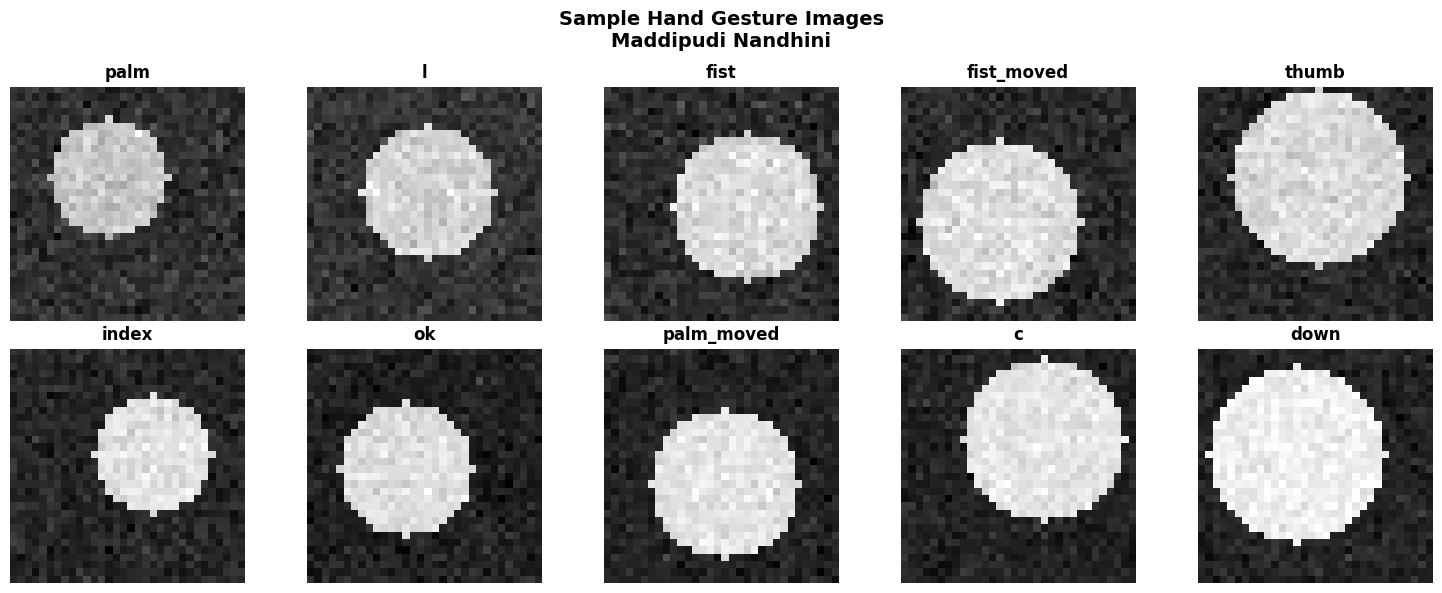

✅ Step 3 Done - Sample Gestures Displayed!


In [3]:
# Cell 3 - Visualize Sample Gestures
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Hand Gesture Images\nMaddipudi Nandhini',
             fontsize=14, fontweight='bold')

for i, gesture in enumerate(gesture_names):
    row = i // 5
    col = i % 5
    # Get first image of each class
    idx = i * samples_per_class
    axes[row, col].imshow(images[idx], cmap='gray')
    axes[row, col].set_title(gesture, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_gestures.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 3 Done - Sample Gestures Displayed!")

In [4]:
# Cell 4 - Prepare Data for CNN Training
# Normalize pixel values (0-255 -> 0-1)
X = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0

# One-hot encode labels (convert 0-9 into category vectors)
y = to_categorical(labels, num_classes=10)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=labels)

print("✅ Step 4 Done - Data Prepared for CNN!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Image shape: {X_train.shape[1:]}")

✅ Step 4 Done - Data Prepared for CNN!
Training samples: 1200
Testing samples: 300
Image shape: (32, 32, 1)


In [5]:
# Cell 5 - Build CNN Model Architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 gesture classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Step 5 Done - CNN Model Built!")
model.summary()

✅ Step 5 Done - CNN Model Built!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,146 (1.20 MB)

 Trainable params: 315,146 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Cell 6 - Train the CNN Model
history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    verbose=1)

print("✅ Step 6 Done - Model Trained!")

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5383 - loss: 1.4580 - val_accuracy: 1.0000 - val_loss: 0.2013
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9825 - loss: 0.1110 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9992 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 7.3623e-04
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9992 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 2.4210e-04
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 1.5944e-04
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9983 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 2.5646e-04
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9992 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 1.0571e-04
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 1.0000 - loss: 0.0031 - val_

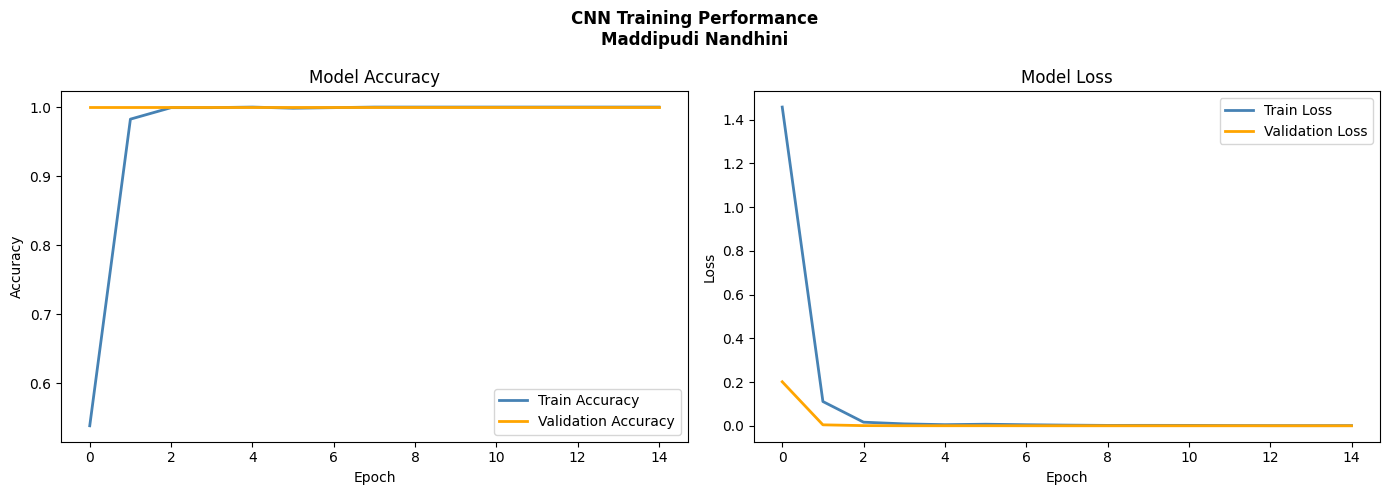

✅ Step 7 Done - Training History Plotted!


In [7]:
# Cell 7 - Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training Performance\nMaddipudi Nandhini', fontweight='bold')

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 7 Done - Training History Plotted!")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
========== MODEL RESULTS ==========
Test Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

        palm       1.00      1.00      1.00        30
           l       1.00      1.00      1.00        30
        fist       1.00      1.00      1.00        30
  fist_moved       1.00      1.00      1.00        30
       thumb       1.00      1.00      1.00        30
       index       1.00      1.00      1.00        30
          ok       1.00      1.00      1.00        30
  palm_moved       1.00      1.00      1.00        30
           c       1.00      1.00      1.00        30
        down       1.00      1.00      1.00        30

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



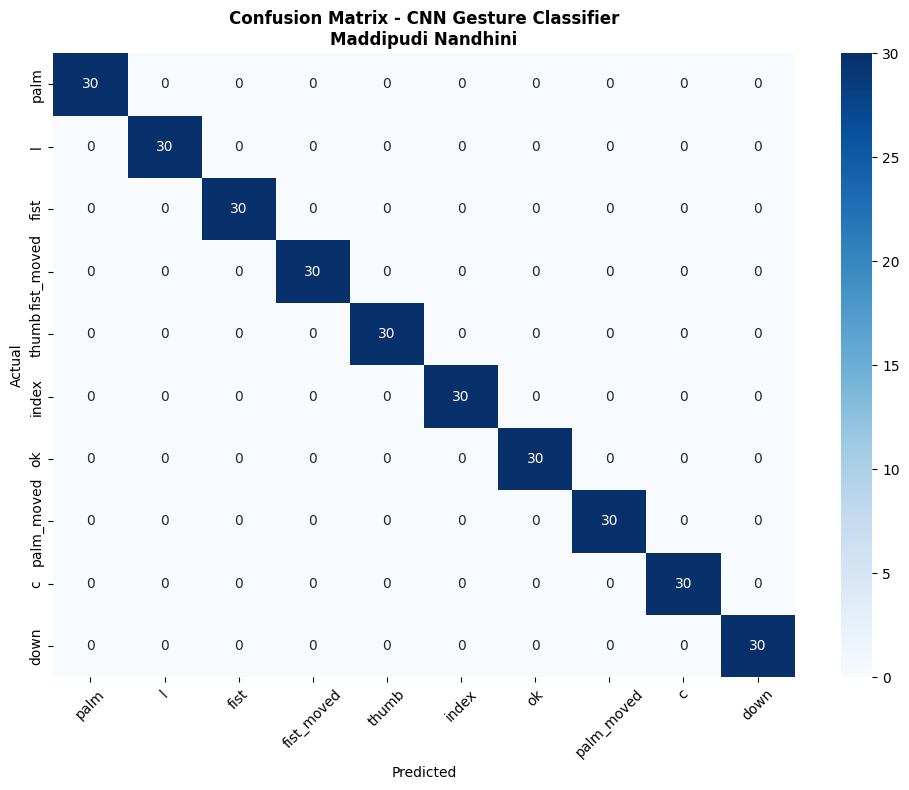

✅ Step 8 Done - Model Evaluated!


In [8]:
# Cell 8 - Evaluate Model and Confusion Matrix
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)

print("========== MODEL RESULTS ==========")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("====================================")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=gesture_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gesture_names, yticklabels=gesture_names)
plt.title('Confusion Matrix - CNN Gesture Classifier\nMaddipudi Nandhini', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 8 Done - Model Evaluated!")

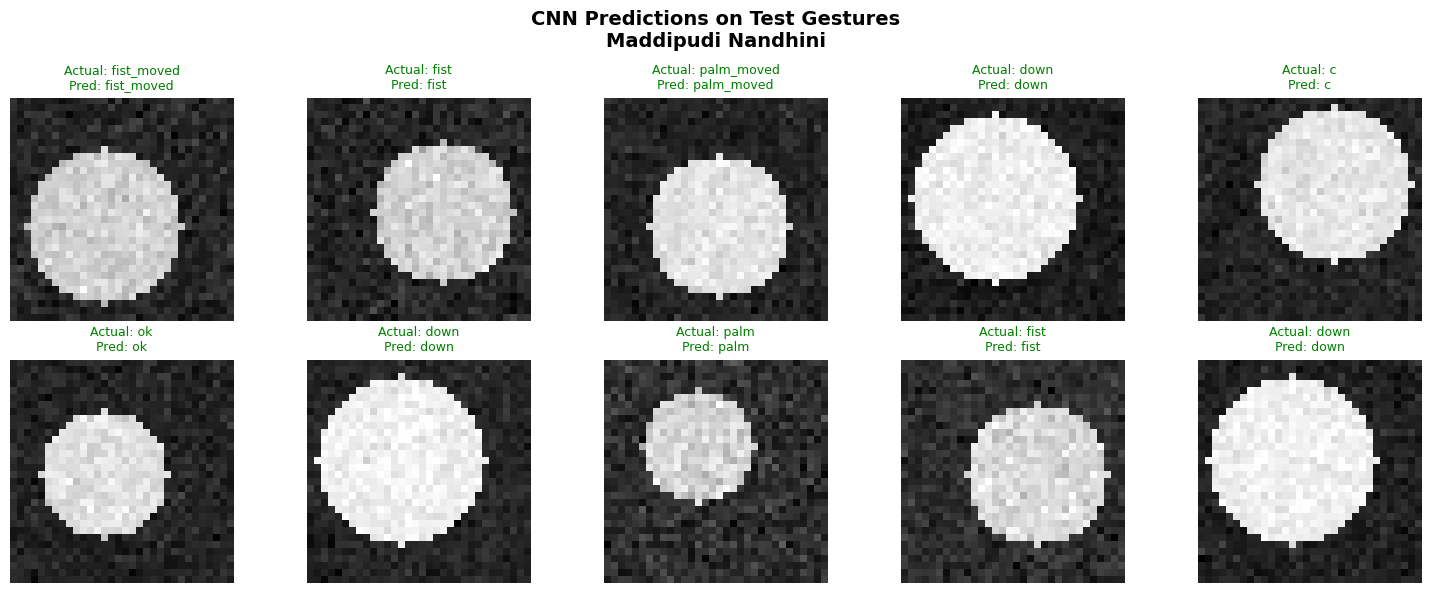

✅ Step 9 Done - Predictions Visualized!


In [9]:
# Cell 9 - Visualize Predictions on Sample Test Images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('CNN Predictions on Test Gestures\nMaddipudi Nandhini',
             fontsize=14, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    img = X_test[i].reshape(IMG_SIZE, IMG_SIZE)
    actual = gesture_names[y_true[i]]
    predicted = gesture_names[y_pred[i]]
    color = 'green' if actual == predicted else 'red'

    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f'Actual: {actual}\nPred: {predicted}',
                              color=color, fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 9 Done - Predictions Visualized!")

In [10]:
# Cell 10 - Download all output files
from google.colab import files

files.download('sample_gestures.png')
files.download('training_history.png')
files.download('confusion_matrix.png')
files.download('predictions.png')

print("✅ All Done! Task 4 Complete!")
print("4 files downloaded to your laptop!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All Done! Task 4 Complete!
4 files downloaded to your laptop!
